In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker

import freealg
from freealg import AlgebraicForm
from freealg.distributions import DeformedMarchenkoPastur
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
title = 'Deformed Marchenko-Pastur'
latex = True

# Option 1: Deformed MP

In [3]:
config1 = dict(
    input_filename = 'deformed_mp_eigs.npz',
    deg_m = 3,
    # effective_n = 80_000,
    xlim = (0.5, 8),
    ylim = [(0.0, 2.55), (0.0, 2.55), (0.0, 0.52)],
    nbins = (80, 120),
    label_mode = 'pow-int',
    save_filename = 'dmp',
)

# -------

config = config1

[(1.005518159668944, 3.1256892314391456), (4.16272377987857, 7.595354543299054)]


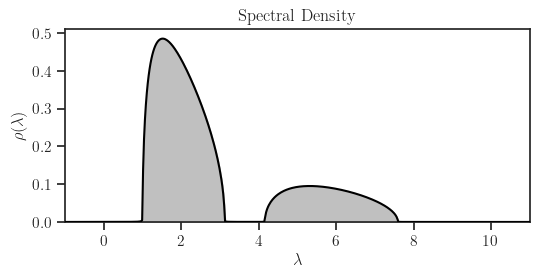

In [7]:
filename = 'deformed_mp'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=lam)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=latex, save=False)

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000



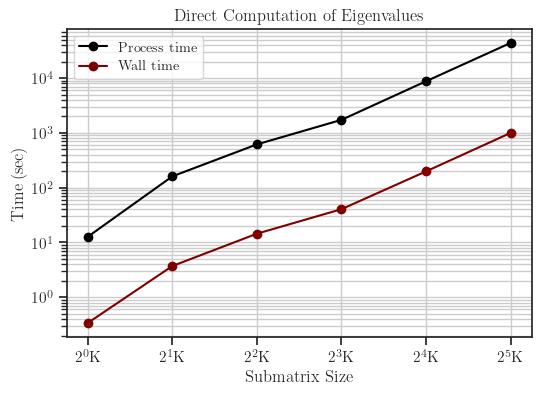

In [4]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')
# print(f'proc name: {proc_name}')
# print(f'num proc:  {num_proc}')
# print(f'date:      {date}')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

# Option 2: STL-10

Idx   Size   Repeat
---  -----   ------
0     1000        8
1     1414        5
2     2000        4
3     2828        2
4     4000        2
5     5656        1
6     8000        1
7    11313        1
8    16000        1

proc name: Intel(R) Xeon(R) Gold 6126 CPU @ 2.60GHz
num proc:  48
date:      2026-05-06 22:01:57 PDT



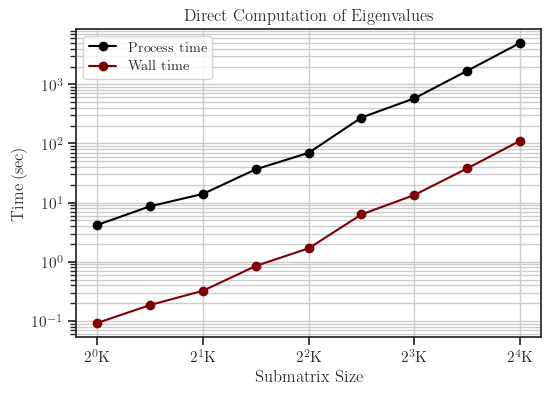

In [2]:
# Load input file
filename = 'stl10_n16K_eigs.npz'  # Original in the paper
# filename = 'stl10_n16K_unormalized_eigs.npz'  # Not normalized
# filename = 'stl10_n16K_syn_eigs.npz'  # Gaussian/Whishart synthetic
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# dir_ = '/home/eecs/sameli/work/scripts/eig/'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 1
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()
    # s = eigs_repeated[i].shape[0]
    # shift = min(s-1, 2)
    # eigs[i] = eigs_repeated[i][shift:shift+rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

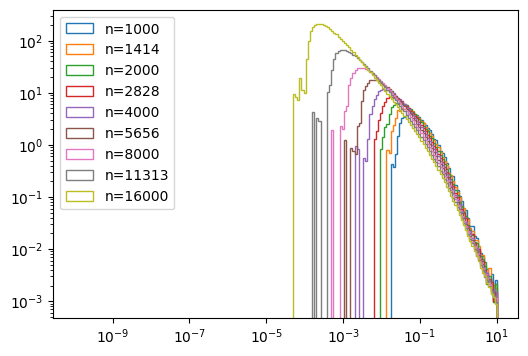

In [3]:
# This dataset has eigenvalues very clsoe to zero, which sometiems they are slightly negative.
for i in range(len(eigs)):
    eigs[i] = numpy.abs(eigs[i])

plt.figure(figsize=(6, 4))

for i in range(len(eigs)):
    vals = eigs[i]
    vals = vals[vals > 1e-12]
    plt.hist(vals, bins=numpy.geomspace(1e-10, 1e1, 200),
             density=True, histtype="step", label=f"n={sizes[i]}")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

# Free Multiplicative Kernel Flows

A multiplicative-kernel Monte Carlo realization of DD by sampling the free-Jacobi/Wachter kernel $\beta_{c, \tau}$ and forming

$$\mathbf{A}_{n} = \mathbf{A}_{n_0}^{\frac{1}{2}} \mathbf{B}_{\mathrm{ker}} \mathbf{A}_{n_0}^{\frac{1}{2}}$$

where the kernel is 

$$ S_{\beta_{c, \tau}} = \frac{1 + c w}{1 + c \tau w} $$

This operation is a Monte-Carlo samplier for

$$ \nu_{\tau} = \nu_1 \boxtimes \beta_{c, \tau}$$

## Quantile Sampler

In [4]:
# =========================
# sample dd kernel quantile
# =========================

from scipy.integrate import cumulative_trapezoid

def sample_dd_kernel_quantile(c, tau, u, n_grid=20_000, log=False):
    a = 1.0 / (c * tau)
    b = (tau - 1.0) / (c * tau)

    lam_p = ((numpy.sqrt(b) + numpy.sqrt(a * (a + b - 1.0))) / (a + b))**2
    lam_m = ((numpy.sqrt(b) - numpy.sqrt(a * (a + b - 1.0))) / (a + b))**2

    x_m = tau * lam_m
    x_p = tau * lam_p

    if log:
        x = numpy.geomspace(x_m, x_p, n_grid)
    else:
        x = numpy.linspace(x_m, x_p, n_grid)
    
    rho = numpy.sqrt((x_p - x) * (x - x_m)) / (2.0 * numpy.pi * c * x * (tau - x))

    # rad = numpy.maximum((x_p - x) * (x - x_m), 0.0)
    # rho = numpy.sqrt(rad) / (2.0 * numpy.pi * c * x * (tau - x))

    cdf = cumulative_trapezoid(rho, x, initial=0.0)
    cdf = cdf / cdf[-1]

    return numpy.interp(u, cdf, x)

In [15]:
Nsim = 4000
start_idx = 0
end_idx = 5
log = True

# c_start = dist.ratio * (sizes[start_idx] / sizes[-1])  # for deformed mp
p = 96 * 96 * 3  # For STL
c_start = sizes[start_idx] / p

tau = sizes[end_idx] / sizes[start_idx]

u = (numpy.arange(Nsim) + 0.5) / Nsim
a0 = numpy.quantile(eigs[start_idx], u)

# a0 = numpy.maximum(a0, 0.0)
eps = 1e-14
if log:
    log_eigs0 = numpy.log(numpy.maximum(eigs[start_idx], eps))
    a0 = numpy.exp(numpy.quantile(log_eigs0, u))
else:
    a0 = numpy.quantile(numpy.maximum(eigs[start_idx], eps), u)

beta_eigs = sample_dd_kernel_quantile(c_start, tau, u, log=log)

rng = numpy.random.default_rng(0)
Q, _ = numpy.linalg.qr(rng.standard_normal((Nsim, Nsim)))

B = (Q * beta_eigs) @ Q.T

sqrt_a0 = numpy.sqrt(a0)
A_tau = (sqrt_a0[:, None] * B) * sqrt_a0[None, :]

eigs_mc = numpy.linalg.eigvalsh(A_tau)

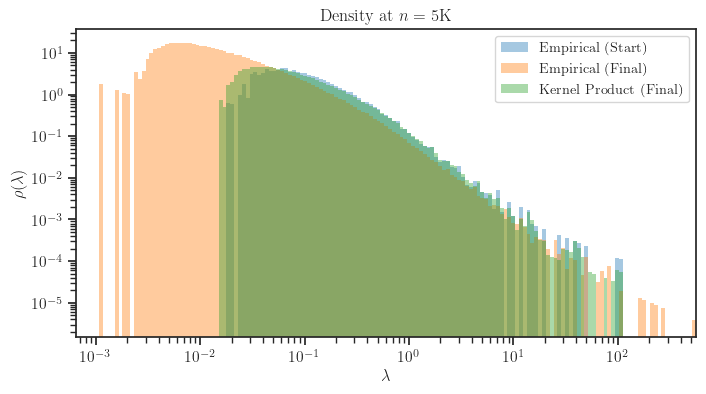

In [16]:
with texplot.theme(use_latex=latex):
    
    fig, ax = plt.subplots(figsize=(8, 4))

    xmin = min(numpy.min(eigs_mc), numpy.quantile(eigs[end_idx], 1e-4))
    xmax = max(numpy.max(eigs_mc), numpy.quantile(eigs[end_idx], 1 - 1e-4))
    
    if log:
        bins = numpy.geomspace(xmin / 5, xmax * 5, 200)
    else:
        bins = numpy.linspace(xmin, xmax, 200)

    ax.hist(eigs[start_idx], bins=bins, density=True, alpha=0.4, edgecolor='none', label='Empirical (Start)')
    ax.hist(eigs[end_idx], bins=bins, density=True, alpha=0.4, edgecolor='none', label='Empirical (Final)')
    ax.hist(eigs_mc, bins=bins, density=True, alpha=0.4, edgecolor='none', label='Kernel Product (Final)')
    
    ax.set_xlim([xmin, xmax])
    ax.set_title(f'Density at $n={{{int(sizes[end_idx]/1000)}}}$K')
    ax.legend(fontsize='small')
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\rho(\lambda)$')

    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    plt.show()

# Normalized Schatten Norm

For a matrix $\mathbb{A} \in \mathbb{R}^{n \times n}$, this normalized Shcatten norm is defined by

$$ \Vert \mathbb{A} \Vert_p = \begin{cases}
\left(\det \mathbf{A} \right)^{\frac{1}{n}}, & p = 0 \\
\left(\frac{1}{n} \mathrm{trace} |\mathbf{A}|^p \right)^{\frac{1}{p}}, & p \neq 0,
\end{cases}
$$

See equation 3 in [this paper](https://arxiv.org/pdf/2009.07385).

In [88]:
def normalized_schatten_from_eigs(eigs, p, eps=0.0,
                                  return_log=False):
    eigs = numpy.asarray(eigs, dtype=float)
    p = numpy.asarray(p, dtype=float)

    if eps > 0:
        eigs = numpy.maximum(eigs, eps)

    if numpy.any(eigs <= 0):
        raise ValueError("Eigenvalues must be positive for p <= 0 or p=0.")

    log_lam = numpy.log(eigs)
    out = numpy.empty_like(p, dtype=float)

    for k, p in enumerate(p):
        if numpy.isclose(p, 0.0):
            log_val = numpy.mean(log_lam)
        else:
            # log((mean lambda^p)^(1/p)) stably
            a = p * log_lam
            amax = numpy.max(a)
            log_mean = amax + numpy.log(numpy.mean(numpy.exp(a - amax)))
            log_val = log_mean / p

        out[k] = log_val if return_log else numpy.exp(log_val)

    return out

In [89]:
p = numpy.linspace(-10, 10, 301)

sch_emp = normalized_schatten_from_eigs(eigs[end_idx], p, eps=1e-14)
sch_pred = normalized_schatten_from_eigs(eigs_mc, p, eps=1e-14)

rel_err = sch_pred / sch_emp - 1.0

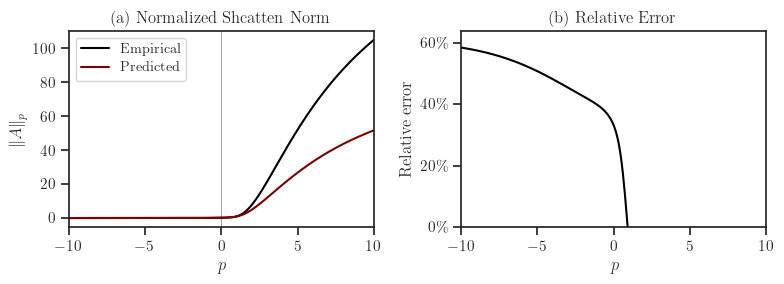

In [90]:
with texplot.theme(use_latex=latex):
    
    fig, ax = plt.subplots(figsize=(8, 3), ncols=2)
    
    ax[0].plot(p, sch_emp, color='black', label='Empirical')
    ax[0].plot(p, sch_pred, color='maroon', label='Predicted')
    ax[0].axvline(0, color='gray', linewidth=0.5, zorder=-2)
    
    ax[0].set_xlabel(r'$p$')
    ax[0].set_ylabel(r'$\|A\|_p$')
    ax[0].legend(fontsize='small')
    ax[0].set_xlim([p[0], p[-1]])
    ax[0].set_title('(a) Normalized Shcatten Norm')


    ax[1].plot(p, 100 * rel_err, color='black')
    ax[1].axhline(0, color='black', linewidth=0.8)
    ax[1].set_xlabel(r'$p$')
    ax[1].set_ylabel(r'Relative error')
    ax[1].set_ylim(bottom=0)
    ax[1].set_xlim([p[0], p[-1]])
    ax[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    ax[1].set_title('(b) Relative Error')

    plt.tight_layout()
    plt.show()

# Cumulant Generating Function

Let $X = \log \lambda$. Then, the cumulant generating function of the logarithm of the eigenvalues is

$$ K(p) = \log \mathbb{E}[e^{p X}] = \log \mathbb{E}[\lambda^p]$$

This is related to normalized Shcatten norm:

$$ \log \Vert \mathbf{A} \Vert_p = \begin{cases}
\frac{1}{p} K(p), & p \neq 0, \\
K'(0), & p = 0
\end{cases}
$$

where $K'(0) = \mathbb{E}[\log \lambda]$ and $K''(0) = \mathbb{V}[\log \lambda]$

In [91]:
def log_mgf_log_eigs(eigs, p, eps=0.0):
    eigs = numpy.asarray(eigs, dtype=float)
    p = numpy.asarray(p, dtype=float)

    if eps > 0:
        eigs = numpy.maximum(eigs, eps)

    if numpy.any(eigs <= 0):
        raise ValueError("Eigenvalues must be positive.")

    log_lam = numpy.log(eigs)
    out = numpy.empty_like(p)

    for k, p in enumerate(p):
        a = p * log_lam
        amax = numpy.max(a)
        out[k] = amax + numpy.log(numpy.mean(numpy.exp(a - amax)))

    return out

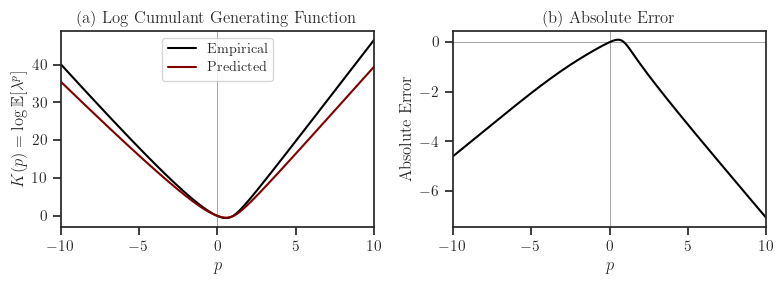

In [92]:
K_emp = log_mgf_log_eigs(eigs[end_idx], p, eps=1e-14)
K_pred = log_mgf_log_eigs(eigs_mc, p, eps=1e-14)

with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(8, 3), ncols=2)

    ax[0].plot(p, K_emp, color='black', label='Empirical')
    ax[0].plot(p, K_pred, color='maroon', label='Predicted')
    ax[0].axvline(0, color='gray', linewidth=0.5, zorder=-2)
    ax[0].set_xlabel(r'$p$')
    ax[0].set_ylabel(r'$K(p)=\log \mathbb{E}[\lambda^p]$')
    ax[0].legend(fontsize='small')
    ax[0].set_xlim([p[0], p[-1]])
    ax[0].set_title('(a) Log Cumulant Generating Function')

    ax[1].plot(p, K_pred - K_emp, color='black')
    ax[1].axhline(0, color='gray', linewidth=0.5, zorder=-2)
    ax[1].axvline(0, color='gray', linewidth=0.5, zorder=-2)
    ax[1].set_xlabel(r'$p$')
    ax[1].set_ylabel(r'Absolute Error')
    ax[1].set_xlim([p[0], p[-1]])
    ax[1].set_title('(b) Absolute Error')

    plt.tight_layout()
    plt.show()